# Sentinel — 03: Engine (Feature Engineering + ML + Kural Motoru)

**Bu notebook'ta yapılacaklar:**
1. Son 3 yıl filtresi (2022-2025)
2. Feature engineering (25+ özellik)
3. readmission_30d etiketi oluştur
4. XGBoost eğit (5-fold CV + SMOTE)
5. SHAP açıklanabilirlik
6. Kontrendikasyon kural tablosu
7. Final Sentinel skoru (ML + kural birleşimi)
8. Demo hasta testi: ANON_018774 + Diklofenak → KIRMIZI

In [1]:


import duckdb
import pandas as pd
import numpy as np
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
from scipy import stats

DB_PATH    = r"C:\Users\Mutlu\Desktop\ACUHIT\sentinel.db"
MODEL_PATH = r"C:\Users\Mutlu\Desktop\ACUHIT\sentinel_model.pkl"
DEMO_HASTA = 'ANON_018774'

con = duckdb.connect(DB_PATH ,read_only=True)
con.execute("SET threads=4")
con.execute("SET memory_limit='4GB'")

print('✅ Bağlantı kuruldu')
print(f'XGBoost: {xgb.__version__}')

✅ Bağlantı kuruldu
XGBoost: 3.0.2


---
## 📅 BÖLÜM 1: Son 3 Yıl Filtresi (2022-2025)

In [3]:
print('=== SON 3 YIL FİLTRESİ ===')

ana_son3 = con.execute("""
    SELECT
        HASTA_ID,
        SQ_EPISODE,
        EPISODE_TARIH,
        TANI_YASI,
        CINSIYET,
        SERVISADI,
        TANIKODU,
        TUM_EPS_TANILAR,
        TOPLAM_GELIS_SAYISI,
        GELIS_SAYISI,
        ILK_TANI_SON_TANI_GUN_FARKI
    FROM ana
    WHERE EPISODE_TARIH >= '2022-01-01'
      AND HASTA_ID IS NOT NULL
      AND HASTA_ID != 'None'
""").fetchdf()

print(f'Son 3 yıl episode sayısı : {len(ana_son3):,}')
print(f'Benzersiz hasta          : {ana_son3["HASTA_ID"].nunique():,}')
print(f'Tarih aralığı            : {ana_son3["EPISODE_TARIH"].min()} → {ana_son3["EPISODE_TARIH"].max()}')

=== SON 3 YIL FİLTRESİ ===
Son 3 yıl episode sayısı : 843,921
Benzersiz hasta          : 39,850
Tarih aralığı            : 2022-01-01 01:01:23 → 2026-02-23 01:06:12


---
## 🏷️ BÖLÜM 2: Etiket Oluştur — readmission_30d

In [4]:
print('=== readmission_30d ETİKETİ OLUŞTURULUYOR ===')

# Her episode için bir sonraki ziyaret tarihini bul
ana_son3 = ana_son3.sort_values(['HASTA_ID', 'EPISODE_TARIH'])
ana_son3['EPISODE_TARIH'] = pd.to_datetime(ana_son3['EPISODE_TARIH'])

# Sonraki ziyaret tarihi
ana_son3['sonraki_ziyaret'] = (
    ana_son3.groupby('HASTA_ID')['EPISODE_TARIH']
    .shift(-1)
)

# Gün farkı
ana_son3['gun_fark'] = (
    ana_son3['sonraki_ziyaret'] - ana_son3['EPISODE_TARIH']
).dt.days

# Etiket: 30 gün içinde tekrar gelmiş mi?
ana_son3['readmission_30d'] = (
    (ana_son3['gun_fark'] > 0) &
    (ana_son3['gun_fark'] <= 30)
).astype(int)

# Son ziyareti olan satırları çıkar (sonraki yok)
ana_son3 = ana_son3[ana_son3['sonraki_ziyaret'].notna()].copy()

pos = ana_son3['readmission_30d'].sum()
neg = len(ana_son3) - pos
oran = pos / len(ana_son3) * 100

print(f'Toplam episode  : {len(ana_son3):,}')
print(f'Readmission=1   : {pos:,} ({oran:.1f}%)')
print(f'Readmission=0   : {neg:,} ({100-oran:.1f}%)')
print(f'Sınıf dengesi   : 1:{neg/pos:.1f} oranında dengesiz → SMOTE uygulanacak')

=== readmission_30d ETİKETİ OLUŞTURULUYOR ===
Toplam episode  : 804,071
Readmission=1   : 44,465 (5.5%)
Readmission=0   : 759,606 (94.5%)
Sınıf dengesi   : 1:17.1 oranında dengesiz → SMOTE uygulanacak


---
## ⚙️ BÖLÜM 3: Feature Engineering (Her Hasta İçin)

In [5]:
print('=== FEATURE ENGINEERING ===')
print('Lab özellikleri çekiliyor (2022-2025)...')

# Lab features — hasta başına özet
lab_features = con.execute("""
    SELECT
        HASTA_ID,
        COUNT(*)                                              AS lab_toplam,
        COUNT(DISTINCT SUB_CODE)                              AS lab_test_cesit,
        ROUND(AVG(CASE WHEN is_abnormal THEN 1.0 ELSE 0.0 END) * 100, 1) AS anormal_oran,
        SUM(CASE WHEN is_abnormal THEN 1 ELSE 0 END)         AS anormal_toplam,

        -- Hemoglobin
        AVG(CASE WHEN SUB_CODE = 'Hemoglobin' THEN RESULT_NUM END)    AS hb_ort,
        MIN(CASE WHEN SUB_CODE = 'Hemoglobin' THEN RESULT_NUM END)    AS hb_min,

        -- Glukoz
        AVG(CASE WHEN SUB_CODE LIKE '%Glukoz%' THEN RESULT_NUM END)   AS glukoz_ort,
        MAX(CASE WHEN SUB_CODE LIKE '%Glukoz%' THEN RESULT_NUM END)   AS glukoz_max,

        -- Kreatinin
        MAX(CASE WHEN SUB_CODE LIKE '%Kreatinin%' THEN RESULT_NUM END) AS kreatinin_max,
        AVG(CASE WHEN SUB_CODE LIKE '%Kreatinin%' THEN RESULT_NUM END) AS kreatinin_ort,

        -- HbA1c
        MAX(CASE WHEN SUB_CODE LIKE '%HBA1c%' OR SUB_CODE LIKE '%HbA1c%'
            THEN RESULT_NUM END)                                        AS hba1c_max,

        -- Potasyum
        MIN(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END)  AS potasyum_min,
        MAX(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END)  AS potasyum_max,

        -- Albumin
        MIN(CASE WHEN SUB_CODE LIKE '%Albumin%' THEN RESULT_NUM END)   AS albumin_min,

        -- Sodyum
        MIN(CASE WHEN SUB_CODE LIKE '%Sodyum%' THEN RESULT_NUM END)    AS sodyum_min

    FROM lab
    WHERE REP_DATE >= '2022-01-01'
      AND HASTA_ID IS NOT NULL
      AND HASTA_ID != 'None'
    GROUP BY HASTA_ID
""").fetchdf()

print(f'Lab features: {len(lab_features):,} hasta, {lab_features.shape[1]} özellik')

=== FEATURE ENGINEERING ===
Lab özellikleri çekiliyor (2022-2025)...
Lab features: 178,837 hasta, 16 özellik


In [6]:
print('Reçete özellikleri çekiliyor...')

# Reçete features
rec_features = con.execute("""
    SELECT
        HASTA_ID,
        COUNT(DISTINCT "İlaç Adı")  AS ilac_cesit,
        COUNT(*)                     AS recete_toplam,

        -- Polifarmasi (5+ ilaç)
        CASE WHEN COUNT(DISTINCT "İlaç Adı") >= 5 THEN 1 ELSE 0 END AS polifarmasi,

        -- NSAİİ kullanımı
        MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%naproksen%'
                   OR LOWER("İlaç Adı") LIKE '%diklofenak%'
                   OR LOWER("İlaç Adı") LIKE '%ibuprofen%'
                   OR LOWER("İlaç Adı") LIKE '%arveles%'
                   OR LOWER("İlaç Adı") LIKE '%voltaren%'
                   OR LOWER("İlaç Adı") LIKE '%majezik%'
                   OR LOWER("İlaç Adı") LIKE '%cataflam%'
            THEN 1 ELSE 0 END)       AS nsaii_gecmis,

        -- Antikoagülan
        MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%warfarin%'
                   OR LOWER("İlaç Adı") LIKE '%xarelto%'
                   OR LOWER("İlaç Adı") LIKE '%eliquis%'
                   OR LOWER("İlaç Adı") LIKE '%clexane%'
                   OR LOWER("İlaç Adı") LIKE '%coumadin%'
            THEN 1 ELSE 0 END)       AS antikoagulan,

        -- Diyabet ilacı
        MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%metformin%'
                   OR LOWER("İlaç Adı") LIKE '%janumet%'
                   OR LOWER("İlaç Adı") LIKE '%jardiance%'
                   OR LOWER("İlaç Adı") LIKE '%ozempic%'
                   OR LOWER("İlaç Adı") LIKE '%insulin%'
            THEN 1 ELSE 0 END)       AS diyabet_ilac

    FROM rec
    WHERE RECETE_TARIH >= '2022-01-01'
      AND HASTA_ID IS NOT NULL
      AND HASTA_ID != 'None'
    GROUP BY HASTA_ID
""").fetchdf()

print(f'Rec features: {len(rec_features):,} hasta, {rec_features.shape[1]} özellik')

Reçete özellikleri çekiliyor...
Rec features: 164,013 hasta, 7 özellik


In [7]:
print('Ana veri özellikleri hazırlanıyor...')

# Ana veri features — hasta başına özet
ana_features = ana_son3.groupby('HASTA_ID').agg(
    yas                = ('TANI_YASI', 'max'),
    n_ziyaret          = ('SQ_EPISODE', 'count'),
    n_bolum            = ('SERVISADI', 'nunique'),
    toplam_gelis       = ('TOPLAM_GELIS_SAYISI', 'max'),
    kronik_gun         = ('ILK_TANI_SON_TANI_GUN_FARKI', 'max'),
    readmission_30d    = ('readmission_30d', 'max'),
).reset_index()

# Cinsiyet encode
cinsiyet_map = ana_son3.groupby('HASTA_ID')['CINSIYET'].first().reset_index()
cinsiyet_map['cinsiyet_e'] = (cinsiyet_map['CINSIYET'] == 'E').astype(int)
ana_features = ana_features.merge(cinsiyet_map[['HASTA_ID','cinsiyet_e']], on='HASTA_ID', how='left')

# ICD kategorisi — C (kanser), E (endokrin/diyabet), I (kardio), J (solunum)
icd_map = ana_son3.groupby('HASTA_ID')['TANIKODU'].first().reset_index()
icd_map['icd_kategori'] = icd_map['TANIKODU'].str[0].fillna('Z')
ana_features = ana_features.merge(icd_map[['HASTA_ID','icd_kategori']], on='HASTA_ID', how='left')

# ICD kategorisini numerik yap
le = LabelEncoder()
ana_features['icd_num'] = le.fit_transform(ana_features['icd_kategori'].fillna('Z'))

# Kanser bayrağı
kanser_map = ana_son3.groupby('HASTA_ID')['TUM_EPS_TANILAR'].first().reset_index()
kanser_map['kanser_gecmis'] = kanser_map['TUM_EPS_TANILAR'].str.contains(r'\bC\d', na=False).astype(int)
ana_features = ana_features.merge(kanser_map[['HASTA_ID','kanser_gecmis']], on='HASTA_ID', how='left')

print(f'Ana features: {len(ana_features):,} hasta, {ana_features.shape[1]} özellik')

Ana veri özellikleri hazırlanıyor...
Ana features: 36,000 hasta, 11 özellik


In [8]:
print('Özellikler birleştiriliyor...')

# Tüm featureları birleştir
df_ml = ana_features.merge(lab_features, on='HASTA_ID', how='left')
df_ml = df_ml.merge(rec_features, on='HASTA_ID', how='left')

# Türetilmiş özellikler
# GFR tahmini (CKD-EPI basitleştirilmiş — kreatinin tabanlı)
df_ml['gfr_tahmini'] = np.where(
    df_ml['kreatinin_max'].notna() & (df_ml['kreatinin_max'] > 0),
    141 * np.minimum(df_ml['kreatinin_max'] / 0.9, 1) ** (-0.411) *
    np.maximum(df_ml['kreatinin_max'] / 0.9, 1) ** (-1.209) *
    (0.993 ** df_ml['yas'].fillna(60)),
    np.nan
)

# Böbrek yetmezliği bayrağı (GFR < 60)
df_ml['bobrek_risk'] = (df_ml['gfr_tahmini'] < 60).astype(int)

# Diyabet bayrağı (HbA1c > 6.5 veya glukoz > 126)
df_ml['diyabet_risk'] = (
    (df_ml['hba1c_max'] > 6.5) |
    (df_ml['glukoz_ort'] > 126)
).astype(int)

# Anemi bayrağı (Hb < 12 erkek, < 11 kadın — basitleştirilmiş)
df_ml['anemi_risk'] = (df_ml['hb_min'] < 11.5).astype(int)

# Hipoalbuminemi (beslenme/kronik hastalık)
df_ml['albumin_risk'] = (df_ml['albumin_min'] < 3.5).astype(int)

# Yaşlı hasta (75+)
df_ml['yasli'] = (df_ml['yas'] >= 75).astype(int)

print(f'Final dataset: {len(df_ml):,} hasta, {df_ml.shape[1]} özellik')
print(f'Readmission=1 oranı: %{df_ml["readmission_30d"].mean()*100:.1f}')
print(f'\nÖzellik listesi:')
print([c for c in df_ml.columns if c not in ['HASTA_ID','icd_kategori']])

Özellikler birleştiriliyor...
Final dataset: 36,000 hasta, 38 özellik
Readmission=1 oranı: %40.4

Özellik listesi:
['yas', 'n_ziyaret', 'n_bolum', 'toplam_gelis', 'kronik_gun', 'readmission_30d', 'cinsiyet_e', 'icd_num', 'kanser_gecmis', 'lab_toplam', 'lab_test_cesit', 'anormal_oran', 'anormal_toplam', 'hb_ort', 'hb_min', 'glukoz_ort', 'glukoz_max', 'kreatinin_max', 'kreatinin_ort', 'hba1c_max', 'potasyum_min', 'potasyum_max', 'albumin_min', 'sodyum_min', 'ilac_cesit', 'recete_toplam', 'polifarmasi', 'nsaii_gecmis', 'antikoagulan', 'diyabet_ilac', 'gfr_tahmini', 'bobrek_risk', 'diyabet_risk', 'anemi_risk', 'albumin_risk', 'yasli']


---
## 🤖 BÖLÜM 4: XGBoost Model Eğitimi

In [9]:
print('=== MODEL EĞİTİMİ ===')

# Feature kolonları
FEATURE_COLS = [
    'yas', 'cinsiyet_e', 'n_ziyaret', 'n_bolum',
    'toplam_gelis', 'kronik_gun', 'icd_num',
    'kanser_gecmis',
    # Lab
    'lab_toplam', 'lab_test_cesit', 'anormal_oran', 'anormal_toplam',
    'hb_ort', 'hb_min', 'glukoz_ort', 'glukoz_max',
    'kreatinin_max', 'kreatinin_ort', 'hba1c_max',
    'potasyum_min', 'potasyum_max', 'albumin_min', 'sodyum_min',
    # Reçete
    'ilac_cesit', 'recete_toplam', 'polifarmasi',
    'nsaii_gecmis', 'antikoagulan', 'diyabet_ilac',
    # Türetilmiş
    'gfr_tahmini', 'bobrek_risk', 'diyabet_risk',
    'anemi_risk', 'albumin_risk', 'yasli'
]

# Mevcut colonları filtrele
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_ml.columns]

# Train verisi hazırla
df_train = df_ml[FEATURE_COLS + ['readmission_30d']].dropna(subset=['readmission_30d'])
X = df_train[FEATURE_COLS].fillna(df_train[FEATURE_COLS].median())
y = df_train['readmission_30d'].astype(int)

print(f'Eğitim seti: {len(X):,} hasta')
print(f'Feature sayısı: {len(FEATURE_COLS)}')
print(f'Pozitif (readmission=1): {y.sum():,} (%{y.mean()*100:.1f})')

# SMOTE — sınıf dengesizliği
print('\nSMOTE uygulanıyor...')
sm = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = sm.fit_resample(X, y)
print(f'SMOTE sonrası: {len(X_res):,} örnek (dengeli)')

=== MODEL EĞİTİMİ ===
Eğitim seti: 36,000 hasta
Feature sayısı: 35
Pozitif (readmission=1): 14,544 (%40.4)

SMOTE uygulanıyor...
SMOTE sonrası: 42,912 örnek (dengeli)


In [10]:
# XGBoost eğitimi
print('XGBoost eğitiliyor (5-fold CV)...')

model = xgb.XGBClassifier(
    n_estimators    = 300,
    max_depth       = 6,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 5,
    gamma           = 1,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    use_label_encoder=False,
    eval_metric     = 'auc',
    random_state    = 42,
    n_jobs          = -1
)

# 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(model, X_res, y_res, cv=cv, scoring='roc_auc')
f1_scores  = cross_val_score(model, X_res, y_res, cv=cv, scoring='f1')

print(f'\n=== 5-Fold Cross Validation Sonuçları ===')
print(f'AUC-ROC : {auc_scores.mean():.3f} ± {auc_scores.std():.3f}')
print(f'F1 Macro: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}')
for i, (a, f) in enumerate(zip(auc_scores, f1_scores)):
    print(f'  Fold {i+1}: AUC={a:.3f}  F1={f:.3f}')

# Final model — tüm veriyle eğit
print('\nFinal model eğitiliyor...')
model.fit(X_res, y_res)

# Kaydet
with open(MODEL_PATH, 'wb') as f:
    pickle.dump({'model': model, 'features': FEATURE_COLS, 'median': X.median().to_dict()}, f)

print(f'✅ Model kaydedildi: {MODEL_PATH}')

XGBoost eğitiliyor (5-fold CV)...

=== 5-Fold Cross Validation Sonuçları ===
AUC-ROC : 0.967 ± 0.001
F1 Macro: 0.897 ± 0.002
  Fold 1: AUC=0.967  F1=0.896
  Fold 2: AUC=0.967  F1=0.900
  Fold 3: AUC=0.966  F1=0.895
  Fold 4: AUC=0.965  F1=0.896
  Fold 5: AUC=0.968  F1=0.898

Final model eğitiliyor...
✅ Model kaydedildi: C:\Users\Mutlu\Desktop\ACUHIT\sentinel_model.pkl


---
## 🔍 BÖLÜM 5: SHAP Açıklanabilirlik

=== SHAP ANALİZİ ===


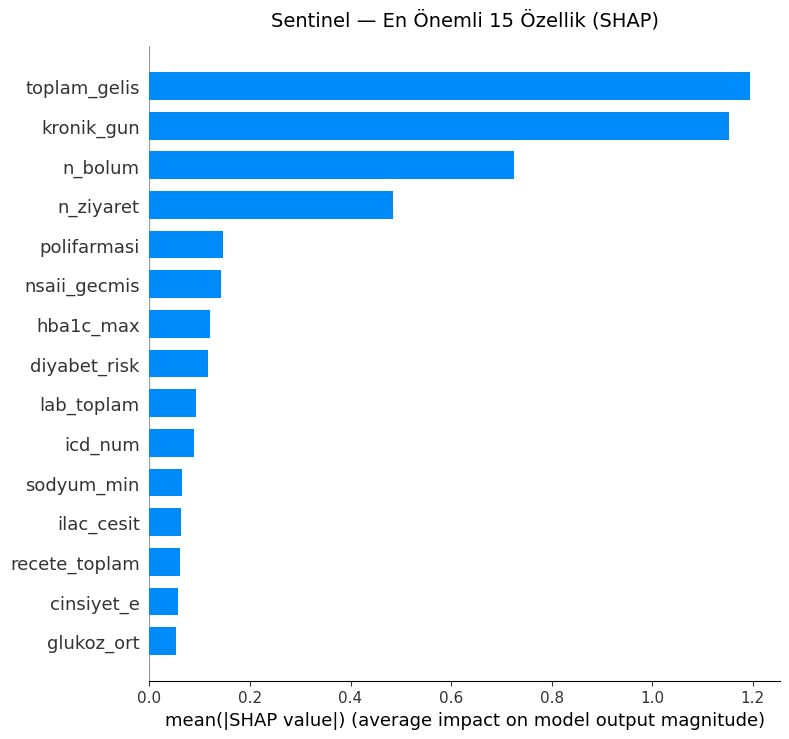

✅ SHAP grafiği kaydedildi


In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print('=== SHAP ANALİZİ ===')

# SHAP değerleri — sample üzerinde
explainer = shap.TreeExplainer(model)

# 1000 örnek al (hız için)
X_sample = X_res.sample(min(1000, len(X_res)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Feature importance grafiği
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('Sentinel — En Önemli 15 Özellik (SHAP)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(r'C:\Users\Mutlu\Desktop\ACUHIT\shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP grafiği kaydedildi')

---
## 📋 BÖLÜM 6: Kontrendikasyon Kural Tablosu

In [12]:
# Kontrendikasyon kural tablosu
# Her kural: ilaç grubu → kontrol → eşik → şiddet → mesaj

KURAL_TABLOSU = [
    # ── NSAİİ KURALLARI ──────────────────────────────────────
    {
        'ilaç_grubu'  : 'NSAİİ',
        'ilaçlar'     : ['diklofenak','naproksen','ibuprofen','arveles',
                         'voltaren','majezik','cataflam','geralgine'],
        'kontrol'     : 'gfr',
        'esik'        : 60,
        'operator'    : '<',
        'siddet'      : 'KIRMIZI',
        'puan_kesinti': 60,
        'mesaj'       : 'GFR < 60 — Böbrek yetmezliği. NSAİİ akut böbrek hasarını hızlandırır.',
        'alternatif'  : 'Parasetamol 500-1000 mg veya topikal diklofenak jel'
    },
    {
        'ilaç_grubu'  : 'NSAİİ',
        'ilaçlar'     : ['diklofenak','naproksen','ibuprofen','arveles',
                         'voltaren','majezik','cataflam'],
        'kontrol'     : 'antikoagulan',
        'esik'        : 1,
        'operator'    : '==',
        'siddet'      : 'KIRMIZI',
        'puan_kesinti': 55,
        'mesaj'       : 'Antikoagülan kullanımı + NSAİİ = GİS kanama riski kritik düzeyde artar.',
        'alternatif'  : 'Parasetamol (antikoagülanla güvenli) veya fizik tedavi'
    },
    {
        'ilaç_grubu'  : 'NSAİİ',
        'ilaçlar'     : ['diklofenak','naproksen','ibuprofen','arveles'],
        'kontrol'     : 'hb_min',
        'esik'        : 11,
        'operator'    : '<',
        'siddet'      : 'SARI',
        'puan_kesinti': 30,
        'mesaj'       : 'Düşük hemoglobin öyküsü — NSAİİ GİS kanama riskini artırır.',
        'alternatif'  : 'Parasetamol tercih edilmeli, mide koruyucu eklenebilir'
    },
    {
        'ilaç_grubu'  : 'NSAİİ',
        'ilaçlar'     : ['diklofenak','naproksen','ibuprofen'],
        'kontrol'     : 'diyabet_risk',
        'esik'        : 1,
        'operator'    : '==',
        'siddet'      : 'SARI',
        'puan_kesinti': 20,
        'mesaj'       : 'Diyabetik hasta — NSAİİ diyabetik nefropatide böbrek fonksiyonunu bozabilir.',
        'alternatif'  : 'Parasetamol veya kısa süreli düşük doz NSAİİ + yakın izlem'
    },

    # ── METFORMİN KURALLARI ───────────────────────────────────
    {
        'ilaç_grubu'  : 'Metformin',
        'ilaçlar'     : ['metformin','glifor','glucophage','janumet'],
        'kontrol'     : 'gfr',
        'esik'        : 45,
        'operator'    : '<',
        'siddet'      : 'KIRMIZI',
        'puan_kesinti': 70,
        'mesaj'       : 'GFR < 45 — Metformin laktik asidoz riskini kritik düzeyde artırır.',
        'alternatif'  : 'Sitagliptin (Januvia) veya insülin — nefroloji konsültasyonu önerilir'
    },

    # ── ACE İNHİBİTÖRÜ KURALLARI ─────────────────────────────
    {
        'ilaç_grubu'  : 'ACE_inhibitor',
        'ilaçlar'     : ['ramipril','enalapril','lisinopril','perindopril'],
        'kontrol'     : 'potasyum_max',
        'esik'        : 5.5,
        'operator'    : '>',
        'siddet'      : 'KIRMIZI',
        'puan_kesinti': 65,
        'mesaj'       : 'Hiperkalemi (K > 5.5) + ACE inhibitörü = ölümcül aritmi riski.',
        'alternatif'  : 'Kalsiyum kanal blokörü (amlodipin) veya diüretik + kardiyoloji konsültasyonu'
    },

    # ── STATİN KURALLARI ──────────────────────────────────────
    {
        'ilaç_grubu'  : 'Statin',
        'ilaçlar'     : ['atorvastatin','rosuvastatin','simvastatin','fluvastatin'],
        'kontrol'     : 'albumin_risk',
        'esik'        : 1,
        'operator'    : '==',
        'siddet'      : 'SARI',
        'puan_kesinti': 20,
        'mesaj'       : 'Düşük albumin — statin myopati riskini artırabilir, CPK takibi önerilir.',
        'alternatif'  : 'Düşük doz statin + 4 hafta sonra CPK kontrolü'
    },
]

print(f'✅ {len(KURAL_TABLOSU)} kontrendikasyon kuralı yüklendi')
for k in KURAL_TABLOSU:
    print(f"  [{k['siddet']:<7}] {k['ilaç_grubu']:<15} → {k['kontrol']} {k['operator']} {k['esik']}")

✅ 7 kontrendikasyon kuralı yüklendi
  [KIRMIZI] NSAİİ           → gfr < 60
  [KIRMIZI] NSAİİ           → antikoagulan == 1
  [SARI   ] NSAİİ           → hb_min < 11
  [SARI   ] NSAİİ           → diyabet_risk == 1
  [KIRMIZI] Metformin       → gfr < 45
  [KIRMIZI] ACE_inhibitor   → potasyum_max > 5.5
  [SARI   ] Statin          → albumin_risk == 1


---
## 🎯 BÖLÜM 7: Sentinel Skor Fonksiyonu

In [13]:
def get_hasta_profili(hasta_id, con):
    """Hasta için tüm özellikleri DuckDB'den çek."""

    # Lab özeti
    lab = con.execute(f"""
        SELECT
            AVG(CASE WHEN SUB_CODE='Hemoglobin' THEN RESULT_NUM END)         AS hb_ort,
            MIN(CASE WHEN SUB_CODE='Hemoglobin' THEN RESULT_NUM END)         AS hb_min,
            AVG(CASE WHEN SUB_CODE LIKE '%Glukoz%' THEN RESULT_NUM END)      AS glukoz_ort,
            MAX(CASE WHEN SUB_CODE LIKE '%Kreatinin%' THEN RESULT_NUM END)   AS kreatinin_max,
            MAX(CASE WHEN SUB_CODE LIKE '%HBA1c%' OR SUB_CODE LIKE '%HbA1c%'
                THEN RESULT_NUM END)                                          AS hba1c_max,
            MIN(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END)    AS potasyum_min,
            MAX(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END)    AS potasyum_max,
            MIN(CASE WHEN SUB_CODE LIKE '%Albumin%' THEN RESULT_NUM END)     AS albumin_min,
            COUNT(*) AS lab_toplam,
            SUM(CASE WHEN is_abnormal THEN 1 ELSE 0 END)                     AS anormal_toplam
        FROM lab
        WHERE HASTA_ID = '{hasta_id}'
    """).fetchdf().iloc[0].to_dict()

    # Ana veri
    ana = con.execute(f"""
        SELECT
            MAX(TANI_YASI) AS yas,
            MAX(CINSIYET) AS cinsiyet,
            COUNT(DISTINCT SQ_EPISODE) AS n_ziyaret,
            COUNT(DISTINCT SERVISADI) AS n_bolum,
            MAX(TOPLAM_GELIS_SAYISI) AS toplam_gelis,
            MAX(ILK_TANI_SON_TANI_GUN_FARKI) AS kronik_gun,
            MAX(TANIKODU) AS tanikodu,
            MAX(TUM_EPS_TANILAR) AS tum_tanilar,
            MAX("Özgeçmiş Notu") AS ozgecmis,
            MAX("Muayene Notu") AS muayene_notu,
            MAX("Sürekli Kullandığı İlaçlar") AS surekli_ilaclar
        FROM ana
        WHERE HASTA_ID = '{hasta_id}'
    """).fetchdf().iloc[0].to_dict()

    # Reçete
    rec = con.execute(f"""
        SELECT
            COUNT(DISTINCT "İlaç Adı") AS ilac_cesit,
            MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%clexane%'
                       OR LOWER("İlaç Adı") LIKE '%warfarin%'
                       OR LOWER("İlaç Adı") LIKE '%xarelto%'
                THEN 1 ELSE 0 END) AS antikoagulan,
            MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%metformin%'
                       OR LOWER("İlaç Adı") LIKE '%janumet%'
                       OR LOWER("İlaç Adı") LIKE '%jardiance%'
                THEN 1 ELSE 0 END) AS diyabet_ilac
        FROM rec
        WHERE HASTA_ID = '{hasta_id}'
    """).fetchdf().iloc[0].to_dict()

    profil = {**lab, **ana, **rec}

    # Türetilmiş değerler
    kre = profil.get('kreatinin_max')
    yas = profil.get('yas', 60)
    profil['gfr_tahmini'] = (
        141 * min(kre/0.9, 1)**(-0.411) * max(kre/0.9, 1)**(-1.209) * (0.993**yas)
        if kre and kre > 0 else None
    )
    profil['bobrek_risk']  = 1 if (profil.get('gfr_tahmini') or 100) < 60 else 0
    profil['diyabet_risk'] = 1 if (
        (profil.get('hba1c_max') or 0) > 6.5 or
        (profil.get('glukoz_ort') or 0) > 126
    ) else 0
    profil['anemi_risk']   = 1 if (profil.get('hb_min') or 15) < 11.5 else 0
    profil['albumin_risk'] = 1 if (profil.get('albumin_min') or 4) < 3.5 else 0
    profil['polifarmasi']  = 1 if (profil.get('ilac_cesit') or 0) >= 5 else 0
    profil['yasli']        = 1 if (yas or 0) >= 75 else 0
    profil['cinsiyet_e']   = 1 if profil.get('cinsiyet') == 'E' else 0
    profil['kanser_gecmis']= 1 if profil.get('tum_tanilar') and \
                             'C' in str(profil.get('tum_tanilar', '')) else 0

    return profil


def sentinel_skor(hasta_id, ilac_adi, con, model, FEATURE_COLS, medians):
    """Sentinel ana fonksiyonu — 0-100 skor + durum + açıklama döndürür."""

    profil     = get_hasta_profili(hasta_id, con)
    ilac_lower = ilac_adi.lower()
    uyarilar   = []
    puan_kesinti_toplam = 0
    en_siddetli = 'YEŞİL'
    alternatif  = None

    # ── KURAL MOTORU ─────────────────────────────────────────
    for kural in KURAL_TABLOSU:
        # İlaç eşleşiyor mu?
        eslesen = any(k in ilac_lower for k in kural['ilaçlar'])
        if not eslesen:
            continue

        # Kontrol değeri
        deger = profil.get(kural['kontrol'])
        if deger is None:
            continue

        # Koşul kontrolü
        tetiklendi = False
        if kural['operator'] == '<'  and deger < kural['esik']:  tetiklendi = True
        if kural['operator'] == '>'  and deger > kural['esik']:  tetiklendi = True
        if kural['operator'] == '==' and deger == kural['esik']: tetiklendi = True

        if tetiklendi:
            uyarilar.append({
                'siddet'  : kural['siddet'],
                'mesaj'   : kural['mesaj'],
                'kesinti' : kural['puan_kesinti']
            })
            puan_kesinti_toplam += kural['puan_kesinti']
            if kural['siddet'] == 'KIRMIZI':
                en_siddetli = 'KIRMIZI'
                alternatif  = kural['alternatif']
            elif kural['siddet'] == 'SARI' and en_siddetli == 'YEŞİL':
                en_siddetli = 'SARI'
                alternatif  = kural['alternatif']

    # ── ML SKORU ─────────────────────────────────────────────
    x_hasta = pd.DataFrame([profil])
    for col in FEATURE_COLS:
        if col not in x_hasta.columns:
            x_hasta[col] = medians.get(col, 0)
    x_hasta = x_hasta[FEATURE_COLS].fillna(pd.Series(medians))

    ml_risk_prob = model.predict_proba(x_hasta)[0][1]  # readmission olasılığı
    ml_puan      = (1 - ml_risk_prob) * 100            # Yüksek olasılık = düşük skor

    # ── FİNAL SKOR ───────────────────────────────────────────
    # %60 kural, %40 ML
    kural_puan  = max(0, 100 - puan_kesinti_toplam)
    final_skor  = round(kural_puan * 0.60 + ml_puan * 0.40)
    final_skor  = max(0, min(100, final_skor))

    # Durum belirle
    if final_skor >= 75:
        durum = 'YEŞİL'
    elif final_skor >= 40:
        durum = 'SARI'
    else:
        durum = 'KIRMIZI'

    # KIRMIZI kural varsa override et
    if en_siddetli == 'KIRMIZI':
        durum = 'KIRMIZI'

    return {
        'hasta_id'   : hasta_id,
        'ilac'       : ilac_adi,
        'skor'       : final_skor,
        'durum'      : durum,
        'uyarilar'   : uyarilar,
        'alternatif' : alternatif,
        'ml_risk_prob': round(ml_risk_prob * 100, 1),
        'kural_puan' : kural_puan,
        'profil'     : profil
    }

print('✅ sentinel_skor() fonksiyonu hazır')

✅ sentinel_skor() fonksiyonu hazır


---
## 🔴 BÖLÜM 8: Demo Testi — ANON_018774 + Diklofenak

In [14]:
# Model yükle
with open(MODEL_PATH, 'rb') as f:
    saved = pickle.load(f)
model_loaded  = saved['model']
FEATURE_COLS  = saved['features']
medians       = saved['median']

print('=== DEMO TEST: ANON_018774 + DİKLOFENAK ===')
sonuc = sentinel_skor(
    hasta_id    = 'ANON_018774',
    ilac_adi    = 'diklofenak',
    con         = con,
    model       = model_loaded,
    FEATURE_COLS= FEATURE_COLS,
    medians     = medians
)

# Sonucu yazdır
emoji = {'YEŞİL': '✅', 'SARI': '⚠️', 'KIRMIZI': '🔴'}
print(f"\n{'='*55}")
print(f"  {emoji[sonuc['durum']]}  SENTINEL KARARI: {sonuc['durum']}")
print(f"  SKOR: {sonuc['skor']}/100")
print(f"  ML Readmission Riski: %{sonuc['ml_risk_prob']}")
print(f"{'='*55}")

if sonuc['uyarilar']:
    print(f"\n  ⚠️  TETİKLENEN UYARILAR ({len(sonuc['uyarilar'])}):\n")
    for u in sonuc['uyarilar']:
        print(f"  [{u['siddet']}] {u['mesaj']}")
        print(f"          Puan kesintisi: -{u['kesinti']}")
        print()

if sonuc['alternatif']:
    print(f"  💊 ALTERNATİF ÖNERİ: {sonuc['alternatif']}")

print(f"\n  Hasta bilgileri:")
p = sonuc['profil']
print(f"    Yaş           : {p.get('yas')}")
print(f"    GFR tahmini   : {round(p.get('gfr_tahmini') or 0, 1)}")
print(f"    Antikoagülan  : {'EVET' if p.get('antikoagulan') else 'Hayır'}")
print(f"    Diyabet riski : {'EVET' if p.get('diyabet_risk') else 'Hayır'}")
print(f"    Anemi öyküsü  : {'EVET' if p.get('anemi_risk') else 'Hayır'}")
print(f"    HbA1c max     : {p.get('hba1c_max')}")
print(f"    Glukoz ort    : {round(p.get('glukoz_ort') or 0, 1)}")

=== DEMO TEST: ANON_018774 + DİKLOFENAK ===

  🔴  SENTINEL KARARI: KIRMIZI
  SKOR: 18/100
  ML Readmission Riski: %55.5

  ⚠️  TETİKLENEN UYARILAR (3):

  [KIRMIZI] Antikoagülan kullanımı + NSAİİ = GİS kanama riski kritik düzeyde artar.
          Puan kesintisi: -55

  [SARI] Düşük hemoglobin öyküsü — NSAİİ GİS kanama riskini artırır.
          Puan kesintisi: -30

  [SARI] Diyabetik hasta — NSAİİ diyabetik nefropatide böbrek fonksiyonunu bozabilir.
          Puan kesintisi: -20

  💊 ALTERNATİF ÖNERİ: Parasetamol (antikoagülanla güvenli) veya fizik tedavi

  Hasta bilgileri:
    Yaş           : 81
    GFR tahmini   : 40.7
    Antikoagülan  : EVET
    Diyabet riski : EVET
    Anemi öyküsü  : EVET
    HbA1c max     : 61.0
    Glukoz ort    : 150.2


In [15]:
# 3 senaryo testi — YEŞİL / SARI / KIRMIZI
print('=== 3 SENARYO TESTİ ===')

senaryolar = [
    ('ANON_018774', 'diklofenak',   'KIRMIZI bekleniyor'),
    ('ANON_018774', 'parasetamol',  'YEŞİL bekleniyor'),
    ('ANON_018774', 'atorvastatin', 'SARI bekleniyor (albumin düşük)'),
]

for hasta, ilac, beklenti in senaryolar:
    s = sentinel_skor(hasta, ilac, con, model_loaded, FEATURE_COLS, medians)
    emoji_str = {'YEŞİL': '✅', 'SARI': '⚠️', 'KIRMIZI': '🔴'}[s['durum']]
    print(f"  {emoji_str} {ilac:<20} → Skor: {s['skor']:>3}/100  [{s['durum']}]  ({beklenti})")

print('\n✅ 03_sentinel_engine tamamlandı!')
print('Sonraki adım: 04_nlp_agent.ipynb')

con.close()

=== 3 SENARYO TESTİ ===
  🔴 diklofenak           → Skor:  18/100  [KIRMIZI]  (KIRMIZI bekleniyor)
  ✅ parasetamol          → Skor:  78/100  [YEŞİL]  (YEŞİL bekleniyor)
  ⚠️ atorvastatin         → Skor:  66/100  [SARI]  (SARI bekleniyor (albumin düşük))

✅ 03_sentinel_engine tamamlandı!
Sonraki adım: 04_nlp_agent.ipynb


In [2]:
import duckdb
import pandas as pd
import numpy as np

DB_PATH  = r"C:\Users\Mutlu\Desktop\ACUHIT\sentinel.db"
OUT_PATH = r"C:\Users\Mutlu\Desktop\ACUHIT\ana_features_39k.csv"

con = duckdb.connect(DB_PATH, read_only=True)

# Ana veri — 2022-2025, hasta başına özet
ana = con.execute("""
    SELECT
        HASTA_ID,
        MAX(TANI_YASI)                    AS yas,
        MAX(CINSIYET)                     AS cinsiyet,
        COUNT(DISTINCT SQ_EPISODE)        AS n_ziyaret,
        COUNT(DISTINCT SERVISADI)         AS n_bolum,
        MAX(TOPLAM_GELIS_SAYISI)          AS toplam_gelis,
        MAX(ILK_TANI_SON_TANI_GUN_FARKI)  AS kronik_gun,
        MAX(TANIKODU)                     AS tanikodu,
        MAX(SERVISADI)                    AS son_bolum,
        MAX(CAST(EPISODE_TARIH AS DATE))  AS son_ziyaret
    FROM ana
    WHERE EPISODE_TARIH >= '2022-01-01'
      AND HASTA_ID IS NOT NULL
      AND HASTA_ID != 'None'
    GROUP BY HASTA_ID
""").fetchdf()

# Lab features
lab = con.execute("""
    SELECT
        HASTA_ID,
        COUNT(*)                                                          AS lab_toplam,
        ROUND(AVG(CASE WHEN is_abnormal THEN 1.0 ELSE 0.0 END)*100, 1)  AS anormal_oran,
        AVG(CASE WHEN SUB_CODE='Hemoglobin' THEN RESULT_NUM END)         AS hb_ort,
        MIN(CASE WHEN SUB_CODE='Hemoglobin' THEN RESULT_NUM END)         AS hb_min,
        AVG(CASE WHEN SUB_CODE LIKE '%Glukoz%' THEN RESULT_NUM END)      AS glukoz_ort,
        MAX(CASE WHEN SUB_CODE LIKE '%Kreatinin%' THEN RESULT_NUM END)   AS kreatinin_max,
        MAX(CASE WHEN SUB_CODE LIKE '%HBA1c%' OR SUB_CODE LIKE '%HbA1c%'
            THEN RESULT_NUM END)                                          AS hba1c_max,
        MIN(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END)    AS potasyum_min,
        MAX(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END)    AS potasyum_max,
        MIN(CASE WHEN SUB_CODE LIKE '%Albumin%' THEN RESULT_NUM END)     AS albumin_min,
        MIN(CASE WHEN SUB_CODE LIKE '%Sodyum%' THEN RESULT_NUM END)      AS sodyum_min
    FROM lab
    WHERE REP_DATE >= '2022-01-01'
      AND HASTA_ID IS NOT NULL
    GROUP BY HASTA_ID
""").fetchdf()

# Reçete features
rec = con.execute("""
    SELECT
        HASTA_ID,
        COUNT(DISTINCT "İlaç Adı")   AS ilac_cesit,
        COUNT(*)                      AS recete_toplam,
        MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%clexane%' OR LOWER("İlaç Adı") LIKE '%warfarin%'
                   OR LOWER("İlaç Adı") LIKE '%xarelto%'
            THEN 1 ELSE 0 END)        AS antikoagulan,
        MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%metformin%' OR LOWER("İlaç Adı") LIKE '%janumet%'
                   OR LOWER("İlaç Adı") LIKE '%jardiance%'
            THEN 1 ELSE 0 END)        AS diyabet_ilac,
        MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%diklofenak%' OR LOWER("İlaç Adı") LIKE '%ibuprofen%'
                   OR LOWER("İlaç Adı") LIKE '%naproksen%'
            THEN 1 ELSE 0 END)        AS nsaii_gecmis
    FROM rec
    WHERE RECETE_TARIH >= '2022-01-01'
      AND HASTA_ID IS NOT NULL
    GROUP BY HASTA_ID
""").fetchdf()

# Birleştir
df = ana.merge(lab, on='HASTA_ID', how='left')
df = df.merge(rec, on='HASTA_ID', how='left')

# Türetilmiş kolonlar
df['gfr_tahmini'] = np.where(
    df['kreatinin_max'].notna() & (df['kreatinin_max'] > 0),
    141 * np.minimum(df['kreatinin_max']/0.9, 1)**(-0.411) *
    np.maximum(df['kreatinin_max']/0.9, 1)**(-1.209) *
    (0.993 ** df['yas'].fillna(60)),
    np.nan
)
df['diyabet_risk'] = ((df['hba1c_max'] > 6.5) | (df['glukoz_ort'] > 126)).astype(int)
df['bobrek_risk']  = (df['gfr_tahmini'] < 60).astype(int)
df['anemi_risk']   = (df['hb_min'] < 11.5).astype(int)
df['polifarmasi']  = (df['ilac_cesit'] >= 5).astype(int)

# Kaydet
df.to_csv(OUT_PATH, index=False, encoding='utf-8-sig')

print(f'Kaydedildi: {OUT_PATH}')
print(f'Boyut: {len(df):,} hasta, {df.shape[1]} kolon')
print(f'Dosya boyutu: {os.path.getsize(OUT_PATH)/1024/1024:.1f} MB')
con.close()

Kaydedildi: C:\Users\Mutlu\Desktop\ACUHIT\ana_features_39k.csv
Boyut: 39,850 hasta, 31 kolon
Dosya boyutu: 5.5 MB
